## GBM(Gradient Boosting Machine)

### GBM의 개요 및 실습

부스팅 알고리즘은 여러 개의 약한 학습기(weak learner)를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식입니다. 부스팅의 대표적인 구현은 AdaBoost와 그래디언트 부스트가 있습니다. 에이다 부스트는 오류 데이터에 가중치를 부여함면서 부스팅을 수행하는 대표적인 알고리즘입니다.

GBM도 에이다부스트와 유사하나, 가중치 업데이트를 경사하강법을 이용하는 것이 큰 차이입니다. 오류 값은 실제 값은 실제 값 - 예측값입니다. 분류의 실제 결괏값을 y, 피처를 x1, x2 ~ xn, 그리고 이 피처에 기반한 예측 함수를 F(x) 함수라고 하면 오류식 h(x) = y - F(x)이 됩니다.

GBM은 CART 기반의 다른 알고리즘과 마찬가지로 분류는 물론이고, 회귀도 가능합니다.

In [ ]:
def get_new_feature_name_df(old_feature_name_df):
    feature_name = old_feature_name_df['column_name'].tolist()

    seen = {}
    new_names = []
    for name in feature_name:
        if name in seen:
            seen[name] += 1
            new_names.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            new_names.append(name)

    new_df = old_feature_name_df.copy()
    new_df['column_name'] = new_names
    return new_df

In [ ]:
import pandas as pd

def get_human_dataset():
    feature_name_df = pd.read_csv('/content/features.txt', sep=r'\s+',
                        header=None, names=['column_index','column_name'])

    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    x_train = pd.read_csv('/content/X_train.txt', sep=r'\s+', names=feature_name)
    x_test  = pd.read_csv('/content/X_test.txt',  sep=r'\s+', names=feature_name)

    y_train = pd.read_csv('/content/y_train.txt', sep=r'\s+', header=None, names=['action'])
    y_test  = pd.read_csv('/content/y_test.txt',  sep=r'\s+', header=None, names=['action'])

    return x_train, x_test, y_train, y_test


x_train, x_test, y_train, y_test = get_human_dataset()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print("GBM 정확도 : {0:.4f}".format(gb_accuracy))
print("GBM 수행 시간 : {0:.1f}초".format(time.time() - start_time))

GBM 정확도 : 0.9379
GBM 수행 시간 : 1715.9초


## XGBoost(eXtra Gradient Boost)

### XGBoost 개요

XGBoost는 GBM에 기반하고 있지만, GBM의 단점인 느린 수행 시간 및 과적합 규제 부재 등의 문제를 해결해서 매우 각광을 받고 있습니다. 특히 XGBoost는 병렬 CPU 환경에서 병렬 학습이 가능해 기존 GBM보다 빠르게 학습을 완료할 수 있습니다.

**XGBoost의 장점**

* 뛰어난 예측 성능 - 일반적으로 분류와 회귀 영역에서 뛰어난 예측 성능을 발휘합니다
* GBM 대비 빠른 수행시간 - 일반적인 GBM은 순차적으로 Weak learner가 가중치를 증감하는 방법으로 학습하기 때문에 전반적으로 속도가 느립니다. 하지만 XGBoost는 병렬 수행 및 다양한 기능으로 GBM에 비해 빠른 수행 성능을 보장합니다. 아쉽게도 XGBoost가 일반적인 GBM에 비해 수행 시간이 빠르다는 것이지, 다른 머신러닝 알고리즘에 비해 빠르다는 의미는 아닙니다.
* 과적합 규제 - 표준 GBM의 경우 과적합 규제 기능이 없으나 XGBoost는 자체에 과적합 규제 기능으로 과적합에 좀 더 강한 내구성을 가질 수 있습니다.
* Tree pruning - 일반적으로 GBM은 분할 시 부정 손실이 발생하면 분할을 더 이상 수행하지 않지만, 이러한 방식도 자칫 지나치게 많은 분할을 발생할 수 있습니다. 다른 GBM과 마찬가지로 XGBoost도 max_depth 파라미터로 분할 깊이를 조정하기도 하지만, tree pruning으로 더 이상 긍정 이득이 없는 분할을 가지치기 해서 분할 수를 더 줄이는 추가적인 장점을 가지고 있습니다.
* 자체 내장된 교차검증 - XGBoost는 반복 수행 시마다 내부적으로 학습 데이터 세트에 대한 교차검증을 수행해 최적화된 반복 수행 횟수를 가질 수 있습니다. 지정된 반복 횟수가 아니라 교차 검증을 통해 평가 데이터 세트의 평가 값이 최적화 되면 반복을 중간에 멈출 수 있는 조기 중단 기능이 있습니다.
* 결손값 자체 처리 - XGBoost는 결손값을 자체 처리할 수 있는 기능을 가지고 있습니다.

### XGBoost 설치하기

In [ ]:
!pip install xgboost --upgrade

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

XGBoost 자체적으로 교차 검증, 성능 평가, 피처 중요도 등의 시각화 기능을 가지고 있습니다. 또한 XGBoost는 기본 BGM에서 부족한 다른 여러 가지 성능 향상 기능이 있습니다. 그중에 수행 속도를 향상시키기 위한 대표적인 기능으로 조기 중단 기능이 있습니다.

In [ ]:
import xgboost

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

### 파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측

In [ ]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target
cancer_df = pd.DataFrame(data = features, columns = dataset.feature_names)
cancer_df["target"] = labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


종양의 크기와 모양에 관련된 많은 속성이 숫자형 값으로 돼 있습니다. 타깃 레이블 값의 종류는 악성인 'malignant'가 0값으로, 양성인 'benign'이 1값으로 돼 있습니다.

In [ ]:
print(dataset.target_names)
print(cancer_df["target"].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1 슬라이싱으로 추출
x_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스용 데이터 추출
x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size = 0.2, random_state = 156)

# 위에서 만든 x_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.1, random_state = 156)

print(x_train.shape, x_test.shape)
print(x_tr.shape, x_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


파이썬 래퍼 XGBoost는 사이킷런고 ㅏ여러 가지 차이가 있습니다.

눈에 띄는 차이는 XGBoost만의 전용 데이터 객체인 DMatrix를 사용합니다. 때문에 Numpy 또는 Pandas로 되어 있는 학습용, 검증, 테스트용 데이터 세트를 모두 전용의 데이터 객체인 DMatrix로 생성하여 모델에 입력해야 합니다.

In [ ]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatrix를 생성.
dtr = xgb.DMatrix(data=x_tr, label=y_tr)
dval = xgb.DMatrix(data=x_val, label=y_val)
dtest = xgb.DMatrix(data=x_test , label=y_test)

* max_depth(트리 최대 깊이)는 3
* 학습률 eta는 0.1(XGBClassifier)를 사용할 경우 eta가 아니라 learning_rate입니다.
* 예제 데이터가 0 또는 1 이진 분류이므로 목적함수(objective)는 이진 로지스틱
* 오류 함수의 평가 성능 지표는 logloss
* num_rounds(부스팅 반복 횟수)는 400회

In [ ]:
params = {"max_depth" : 3,
          "eta" : 0.05,
          "objective" : "binary:logistic",
          "eval_metric" : "logloss"
          }
num_rounds = 400

학습 시 XGBoost는 수행 속도를 개선하기 위해 조기 중단 기능을 제공합니다. 조기 중단은 XGBoost가 수행 성능을 개선하기 위해서 더 이상 지표 개선이 없을 경우에 num_boost_round 횟수를 모두 채우지 않고 중간에 반복을 빠져 나올 수 있도록 하는 것입니다.

조기 중단의 성능 평가는 주로 별도의 검증 데이터 세트를 이용합니다.

In [ ]:
# 학습 데이터 셋은 "train" 또는 평가 데이터 셋은 "eval"로 평가합니다
eval_list = [(dtr, "train"), (dval, "eval")] # 또는 eval_list = [(dval, "eval")]만 명기해도 무방

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, early_stopping_rounds = 50, evals = eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

In [ ]:
pred_probs = xgb_model.predict(dtest)
print("predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨")
print(np.round(pred_probs[:10], 3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds = [1 if x > 0.5 else 0 for x in pred_probs]
print("예측값 10개만 표시 :", preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시 : [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score

def get_clf_eval(y_test, pred, pred_proba):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print("오차 행렬")
    print(confusion)
    print("정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}".format(
        accuracy, precision, recall, f1, roc_auc
    ))

In [ ]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740, F1: 0.9740, AUC: 0.9965


이번에는 xgboost 패키지에 내장된 시각화 기능을 수행해 보겠습니다. xgboost의 plot_importance() API는 피처의 중요도를 막대그래프 형식으로 나타냅니다. 기본 평가 지표로 f스코어를 기반으로 해당 피처의 중요도를 나타냅니다. f스코어는 해당 피처가 트리 분할 시 얼마나 자주 사용되었는지를 지표로 나타낸 값입니다.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

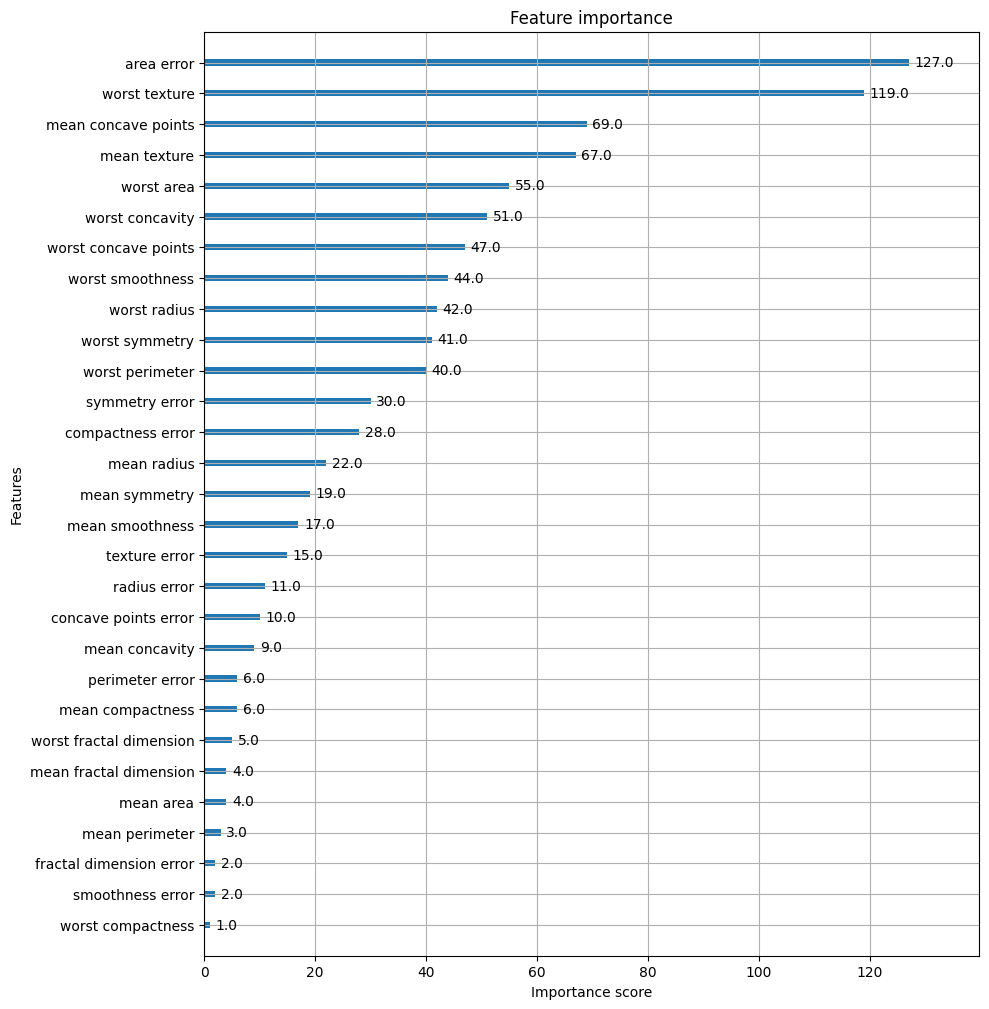

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(xgb_model, ax = ax)

### 사이킷런 래퍼 XGBoost의 개요 및 적용

XGBoost 개발 그룹은 사이킷런의 프레임워크와 연동하기 위해 사이킷런 전용의 XGBoost 래퍼 클래스를 개발했습니다. 사이킷런의 기본 Estimator를 그대로 상속해 만들었기 때문에 다른 Estimator와 동일하게 fit()과 predict()만으로 학습과 예측이 가능하고, GridSearchCV, Pipeline 등 사이킷런의 다른 유틸리티를 그대로 사용할 수 있기 때문에 기존의 다른 머신러닝 알고리즘으로 만들어놓은 프로그램이 있더라도 알고리즘 클래스만 XGboost 래퍼 클래스로 바꾸면 기존 프로그램을 그대로 사용할 수 있습니다.

In [ ]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력
xgb_wrapper = XGBClassifier(n_estimators = 400, learning_rate = 0.05, max_depth = 3)
xgb_wrapper.fit(x_train, y_train, verbose = True)
w_preds = xgb_wrapper.predict(x_test)
w_pred_proba = xgb_wrapper.predict_proba(x_test)[:, 1]

In [ ]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870, F1: 0.9744, AUC: 0.9951


앞 예제의 파이선 래퍼 XGBoost보다 더 좋은 평가 결과가 나왔습니다. 이유는 위스콘신 데이터 세트의 개수가 적은데, 이전에는 조기 중단을 위해서 최초 학습 데이터인 x_train을 다시 학습용 x_tr과 x_val로 분리하면서 최종 학습 데이터 건수가 작아지기 때문에 발생한 것으로 취정됩니다. 위스콘신 데이터 세트가 작기 때문에 전반적으로 검증 데이터를 분리하거나 교차 검증등을 적용할 때 성능 수치가 불안정한 모습을 보입니다. 하지만 데이터 건수가 많은 경우라면, 원본 학습 데이터를 다시 학습과 검증 데이터로 분리하고 여기에 조기 중단 회수를 적절하게 부여할 경우 일반적으로는 과적합을 개선할 수 있어서 모델 성능이 조금 더 향상될 수 있습니다.

In [ ]:
from xgboost import XGBClassifier
import numpy as np

# 데이터 변환
x_tr_np = np.asarray(x_tr, dtype=np.float32)
x_val_np = np.asarray(x_val, dtype=np.float32)
x_test_np = np.asarray(x_test, dtype=np.float32)

y_tr_np = np.asarray(y_tr).reshape(-1)
y_val_np = np.asarray(y_val).reshape(-1)
y_test_np = np.asarray(y_test).reshape(-1)

# early_stopping_rounds, eval_metric은 fit()이 아니라 XGBClassifier() 안에 넣기
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric="logloss",
    random_state=156
)

evals = [(x_tr_np, y_tr_np), (x_val_np, y_val_np)]

xgb_wrapper.fit(
    x_tr_np,
    y_tr_np,
    eval_set=evals,
    verbose=True
)

ws50_preds = xgb_wrapper.predict(x_test_np)
ws50_pred_proba = xgb_wrapper.predict_proba(x_test_np)[:, 1]

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [ ]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740, F1: 0.9740, AUC: 0.9965


조기 중단으로 핛브된 XGBClassifier의 예측 성능의 결과는 파이썬 래퍼의 조기 중단 성능과 동일합니다. 앞에서 설명한 대로 위스콘신 데이터 세트가 워낙 작아서, 조기 중단을 위한 검증 데이터를 분리하면 검증 데이터가 없는 학습 데이터를 사용했을 때보다 성능이 약간 저조합니다.

In [ ]:
from xgboost import XGBClassifier
import numpy as np

# 데이터 변환
x_tr_np = np.asarray(x_tr, dtype=np.float32)
x_val_np = np.asarray(x_val, dtype=np.float32)
x_test_np = np.asarray(x_test, dtype=np.float32)

y_tr_np = np.asarray(y_tr).reshape(-1)
y_val_np = np.asarray(y_val).reshape(-1)
y_test_np = np.asarray(y_test).reshape(-1)

# early_stopping_rounds=10으로 새 모델 생성
xgb_wrapper10 = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=10,
    eval_metric="logloss",
    random_state=156
)

evals = [(x_tr_np, y_tr_np), (x_val_np, y_val_np)]

# 학습
xgb_wrapper10.fit(
    x_tr_np,
    y_tr_np,
    eval_set=evals,
    verbose=True
)

# 예측
ws10_preds = xgb_wrapper10.predict(x_test_np)
ws10_pred_proba = xgb_wrapper10.predict_proba(x_test_np)[:, 1]

# 평가
get_clf_eval(y_test_np, ws10_preds, ws10_pred_proba)

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

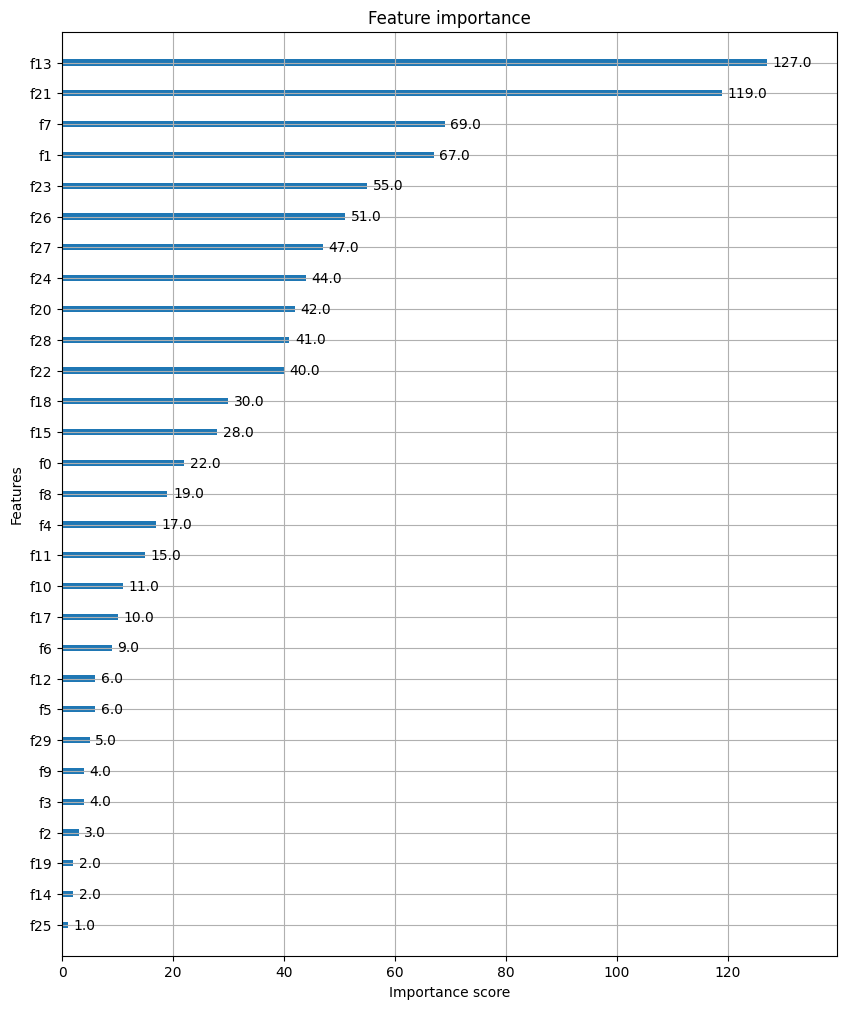

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
# 사이킷런 래퍼 클래스를 입력해도 무방
plot_importance(xgb_wrapper, ax = ax)

## LightGBM

XGBoost는 매우 뛰어난 부스팅 알고리즘이지만, 여전히 학습 시간이 오래 걸립니다. XGBoost에서 GridSearchCV로 하이퍼 파라미터 튜닝을 수행하다 보면 수행 시간이 너무 오래 걸려서 많은 파라미터를 튜닝하기에 어려움을 겪을 수밖에 없습니다. 물론 GBM보다는 빠르지만, 대용량 데이터의 경우 만족할 만한 학습 성능을 기대하려면 많은 CPU 코어를 가진 시스템에서 높은 병렬도로 학습을 진행해야 합니다. 그렇지 않은 H/W로 학습을 진행할 경우에는 당연히 더 많은 시간이 필요하기에 불편함이 커질 수밖에 없습니다.

LightGBM의 가장 큰 장점은 XGBoost보다 학습에 걸리는 시간이 훨씬 적다는 점입니다. 또한 메묄 사용량도 상대적으로 적습니다.

LightGBM과 XGBoost의 예측 성능은 별다른 차이가 없습니다. 또한 가능상의 다양성은 LightGBM이 약간 더 많습니다.

### LightGBM 설치

In [ ]:
!pip install lightgbm==3.3.2

In [ ]:
import lightgbm
from lightgbm import LGBMClassifier

### LightGBM 적용 - 위스콘신 유방암 예측

In [ ]:
# LgithGBM파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)
cancer_df["target"] = dataset.target
x_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size = 0.2, random_state = 156)

# 위에서 만든 x_train, y_train을 다시 조개서 90%는 학습과 10%는 검증용 데이터로 분리
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size = 0.1, random_state = 156)

# 앞서 XGBoost와 동일하게 n_estimators는 400 설정
lgbm_wrapper = LGBMClassifier(n_estimators = 400, learning_rate = 0.05)

# LightGBM도 XGBoost와 동일하게 조기 중단 수행 가능
evals = [(x_tr, y_tr), (x_val, y_val)]
lgbm_wrapper.fit(x_tr, y_tr, early_stopping_rounds = 50, eval_metric = "logloss", eval_set = evals, verbose = True)
preds = lgbm_wrapper.predict(x_test)
pred_proba = lgbm_wrapper.predict_proba(x_test)[:, 1]

[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

In [ ]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740, F1: 0.9677, AUC: 0.9877


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

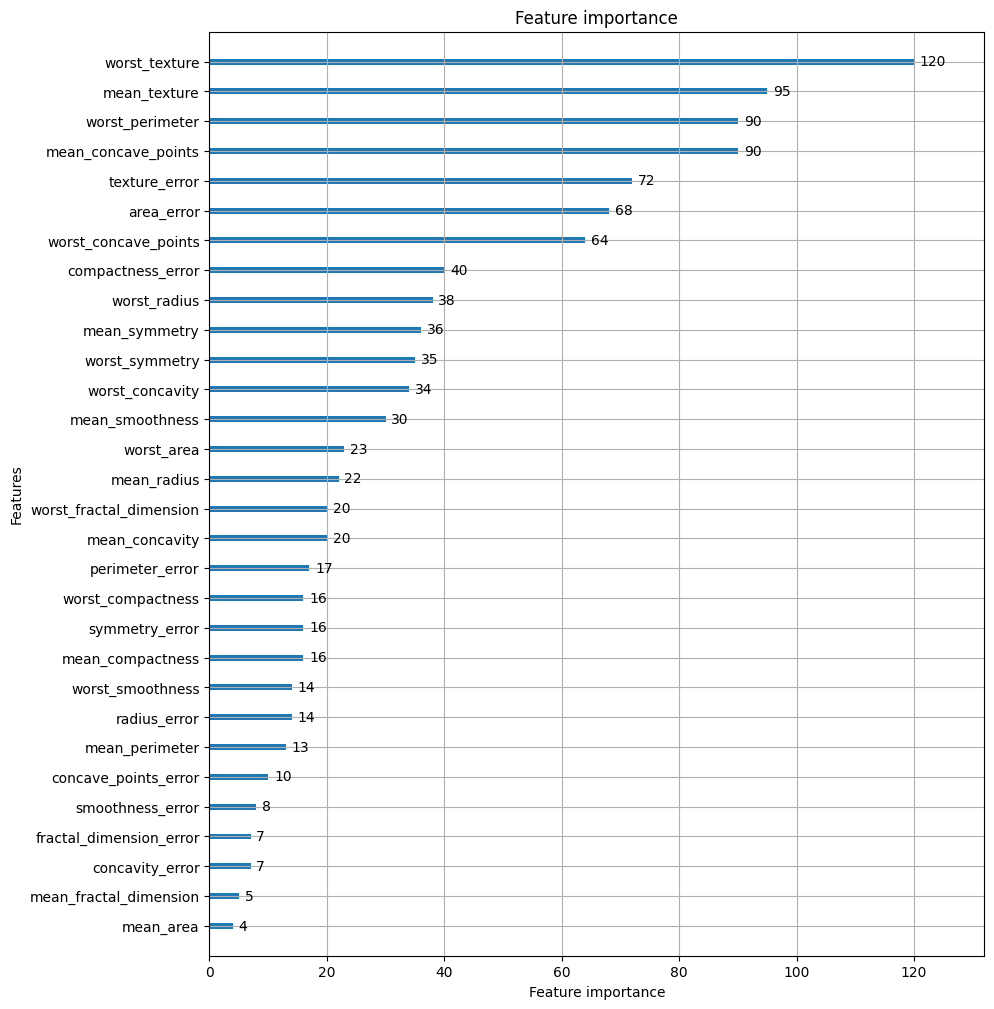

In [ ]:
# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize = (10, 12))
plot_importance(lgbm_wrapper, ax = ax)

## 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝

지금까지는 하이퍼 파라미터 튜닝을 위해서 사이킷런에서 제공하는 Grid Search 방식을 적용했습니다. Grid Search 방식은 한 가지 주요한 단점이 있는데, 튜닝해야 할 하이퍼 파라미터 개수가 많을 경우 최적화 수행 시간이 오래 걸린다는 것입니다. 여기에 개별 하이퍼 파라미터 값의 범위가 넓거나 학습 데이터가 대용량일 경우에는 최적화 시간이 더욱 늘어나게 됩니다.

XGBoost나 LightGBM은 성능이 매우 뛰어난 알고리즘이지만, 하이퍼 파라미터 개수가 다른 알고리즘에 비해서 많습니다. 때문에 실무의 대용량 학습 데아터에 Grid Search 방식으로 최적 하이퍼 파라미터를 찾으려면 많은 시간이 소모될 수 있습니다.

In [ ]:
params = {
    "max_depth": [10, 20, 30, 40, 50],
    "num_leaves": [35, 45, 55, 65],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [10, 20, 30, 40],
    "reg_alpha": [0.01, 0.05, 0.1]
}

이렇게 XGBoost나 LightBoost에 Grid Search를 적용할 경우 기하급수적으로 늘어나는 하이퍼 파라미터 최적화 시간 때문에 어쩔수 없이 하이퍼 파라미터 개수를 줄이거나 개별 하이퍼 파라미터의 범위를 줄여야 합니다.

### 베이지안 최적화 개요

베이지안 최적화는 목적 함수 식을 제대로 알 수 없는 블랙 박스 형태의 함수에서 최대 또는 최소 함수를 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으로 찾아주는 방식입니다.

### HyperOpt 사용하기

HyperOpt를 사용할 때 유의할 점은 다른 패키지와 다르게 목적 함수 반환 값의 최댓값이 아닌 최솟값을 가지는 최적 입력값을 유추한다는 것입니다.

In [ ]:
pip install hyperopt

In [ ]:
from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15 ~ 15까지 1간격으로 입력 변수 y 설정
search_space = {"x" : hp.quniform("x", -10, 10, 1), "y" : hp.quniform("y", -15, 15, 1)}

In [ ]:
from hyperopt import STATUS_OK

# 목적 함수를 생성, 변숫값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
    x = search_space["x"]
    y = search_space["y"]
    retval = x**2 - 20*y

    return retval

In [ ]:
from hyperopt import fmin, tpe, Trials
# 입력 결괏값을 저장한 Trials 객체값 생성
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도(max_evals = 5)로 찾아냄
best_01 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 5, trials = trial_val, rstate = np.random.default_rng(seed = 0))
print("best :", best_01)

100%|██████████| 5/5 [00:00<00:00, 133.51trial/s, best loss: -224.0]
best : {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [ ]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn = objective_func, space = search_space, algo = tpe.suggest, max_evals = 20, trials = trial_val, rstate = np.random.default_rng(seed = 0))
print("best :", best_02)

100%|██████████| 20/20 [00:00<00:00, 167.25trial/s, best loss: -296.0]
best : {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [ ]:
# fmin( )에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 반환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss':함수 반환값, 'status':반환 상태값} 와 같은 딕셔너리임.
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [ ]:
# Trials 객체의 vals 속성에 {'입력변수명':개별 수행 시마다 입력된 값 리스트} 형태로 저장됨.
print(trial_val.vals)

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.float64(-0.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0), np.float64(15.0), np.float64(7.0), np.float64(-10.0), np.float64(0.0), np.float64(-5.0), np.float64(-3.0), np.float64(2.0), np.float64(4.0), np.float64(10.0), np.float64(3.0), np.float64(3.0), np.float64(-14.0), np.float64(-8.0), np.float64(11.0), np.float64(-0.0)]}


In [ ]:
import pandas as pd

# results에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성.
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성.
result_df = pd.DataFrame({'x': trial_val.vals['x'], 'y': trial_val.vals['y'], 'losses': losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


### HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

In [ ]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

# 앞에서 추출한 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )

In [ ]:
from hyperopt import hp

# max_depth는 5에서 20까지 1간격으로, min_child_weight는 1에서 2까지 1간격으로
# colsample_bytree는 0.5에서 1사이, learning_rate는 0.01에서 0.2 사이 정규 분포된 값으로 검색.
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 20, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
                   }

In [ ]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

# fmin()에서 입력된 search_space 값으로 입력된 모든 값은 실수형임.
# XGBClassifier의 정수형 하이퍼 파라미터는 정수형 변환을 해줘야 함.
# 정확도는 높을수록 더 좋은 수치임. -1 * 정확도를 곱해서 큰 정확도 값일수록 최소가 되도록 변환
def objective_func(search_space):
    # 수행 시간 절약을 위해 nestimators는 100으로 축소
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            learning_rate=search_space['learning_rate'],
                            colsample_bytree=search_space['colsample_bytree'],
                            eval_metric='logloss')
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # accuracy는 cv=3 개수만큼 roc-auc 결과를 리스트로 가짐. 이를 평균해서 반환하되 -1을 곱함.
    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK}

In [ ]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=50, # 최대 반복 횟수를 지정합니다.
            trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)

100%|██████████| 50/50 [00:24<00:00,  2.01trial/s, best loss: -0.9670616939700244]
best: {'colsample_bytree': np.float64(0.858999866296754), 'learning_rate': np.float64(0.17459146963933464), 'max_depth': np.float64(20.0), 'min_child_weight': np.float64(2.0)}


In [ ]:
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.859, learning_rate:0.17459, max_depth:20, min_child_weight:2


In [ ]:
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(
    X_tr,
    y_tr,
    eval_set=evals,
    verbose=True
)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.53178	validation_1-logloss:0.57774
[1]	validation_0-logloss:0.43693	validation_1-logloss:0.53104
[2]	validation_0-logloss:0.36375	validation_1-logloss:0.46939
[3]	validation_0-logloss:0.30808	validation_1-logloss:0.42846
[4]	validation_0-logloss:0.26254	validation_1-logloss:0.39423
[5]	validation_0-logloss:0.22780	validation_1-logloss:0.36739
[6]	validation_0-logloss:0.19887	validation_1-logloss:0.35126
[7]	validation_0-logloss:0.17442	validation_1-logloss:0.33290
[8]	validation_0-logloss:0.15590	validation_1-logloss:0.31895
[9]	validation_0-logloss:0.13757	validation_1-logloss:0.30455
[10]	validation_0-logloss:0.12339	validation_1-logloss:0.29727
[11]	validation_0-logloss:0.11020	validation_1-logloss:0.28950
[12]	validation_0-logloss:0.09900	validation_1-logloss:0.28643
[13]	validation_0-logloss:0.09022	validation_1-logloss:0.28405
[14]	validation_0-logloss:0.08217	validation_1-logloss:0.27688
[15]	validation_0-logloss:0.07616	validation_1-logloss:0.27643
[1

In [ ]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[35  2]
 [ 3 74]]
정확도: 0.9561, 정밀도: 0.9737, 재현율: 0.9610, F1: 0.9673, AUC: 0.9944
